In [1]:
import numpy as np
from sklearn.datasets import make_regression
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
X,y = make_regression(n_samples = 100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [3]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})

In [4]:
df.shape

(100, 3)

In [5]:
df.head()

,feature1,feature2,target
0,-0.455140,1.385416,-78.812313
1,1.026489,-0.114444,126.279907
2,-1.698526,-0.727031,-255.911895
3,0.358390,0.022319,-16.277047
4,1.396884,-0.431273,196.553166


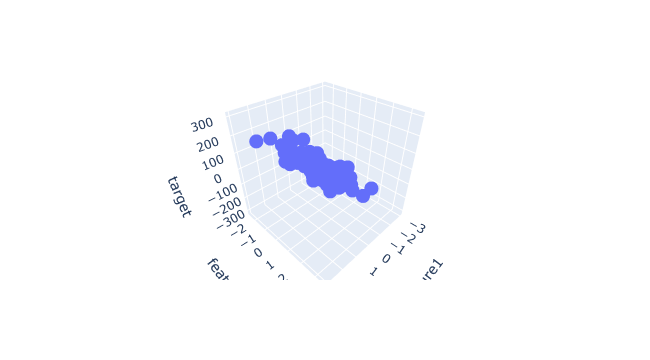

In [6]:
fig = px.scatter_3d(df,x='feature1',y='feature2',z='target')
fig.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
s = StandardScaler()
s.fit_transform(X_train)
s.transform(X_test)

array([[-0.93870011, -0.90192888],
       [ 0.14432162,  0.12291881],
       [ 0.22686094,  0.4649832 ],
       [-1.83269016, -0.17858321],
       [-0.49507178,  0.13220324],
       [ 0.37771333,  0.39081677],
       [-0.556974  , -0.59446213],
       [-2.8380026 , -1.50965146],
       [-0.35887211, -0.64304842],
       [-1.03534544, -0.68373679],
       [-0.66566916,  1.0618996 ],
       [-0.68153454,  0.36738955],
       [-0.13262587, -0.25682726],
       [ 0.10243545, -1.48537151],
       [-2.41399072, -0.21694724],
       [ 0.59558564,  1.07215376],
       [-1.09581425,  1.29059377],
       [ 1.26778203,  0.97212477],
       [-0.83990255, -1.97524255],
       [-1.0065819 ,  2.61025806]])

In [13]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(X_test)

In [15]:
print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 32.173567407926356
MSE 1702.1501963333008
R2 score 0.862758899538425


In [18]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(x, y)

final = np.column_stack((xGrid.ravel(), yGrid.ravel()))

z_final = lr.predict(final).reshape(10, 10)
z = z_final

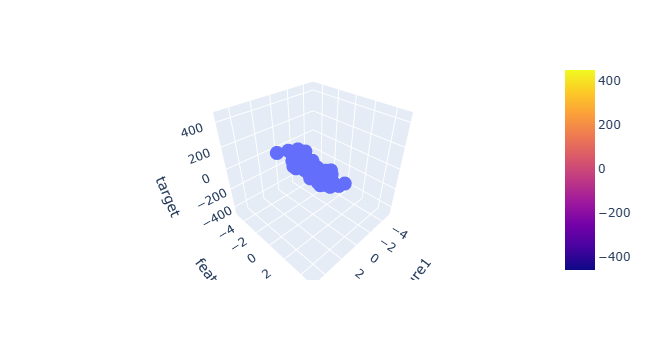

In [19]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [22]:
lr.coef_ # this is m i.e beta

array([90.19491603,  0.57958627])

In [23]:
lr.intercept_

np.float64(-6.957942194614841)